<a href="https://colab.research.google.com/github/Krishishah7/ai-learning-series/blob/main/01_machine_learning_foundations/40_feature_importance_random_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score

In [2]:
X, y = make_classification(
    n_samples=500,
    n_features=10,
    n_informative=5,
    random_state=42
)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [4]:
rf = RandomForestClassifier(
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

RandomForestClassifier(random_state=42)

In [5]:
importance = pd.DataFrame({
    "Feature": range(X.shape[1]),
    "Importance": rf.feature_importances_
})

importance

,Feature,Importance
0,0,0.201372
1,1,0.186734
2,2,0.070669
3,3,0.089752
4,4,0.029010
5,5,0.170865
6,6,0.032693
7,7,0.092161
8,8,0.089520
9,9,0.037224


In [6]:
importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
0,0,0.201372
1,1,0.186734
5,5,0.170865
7,7,0.092161
3,3,0.089752
8,8,0.089520
2,2,0.070669
9,9,0.037224
6,6,0.032693
4,4,0.029010


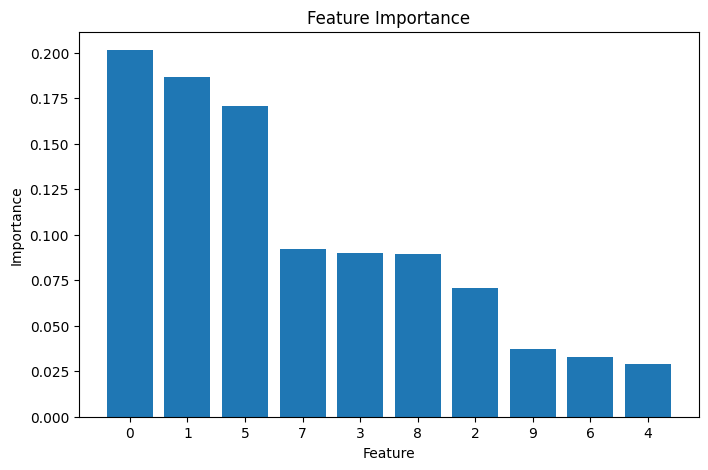

In [7]:
plt.figure(figsize=(8,5))

plt.bar(
    importance["Feature"].astype(str),
    importance["Importance"]
)

plt.xlabel("Feature")

plt.ylabel("Importance")

plt.title(
    "Feature Importance"
)

plt.show()

In [8]:
top_features = importance.head(5)

top_features

,Feature,Importance
0,0,0.201372
1,1,0.186734
5,5,0.170865
7,7,0.092161
3,3,0.089752


In [9]:
selected_features = top_features["Feature"].tolist()

X_selected = X[:, selected_features]

In [10]:
X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(
    X_selected,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
rf_selected = RandomForestClassifier(
    random_state=42
)

rf_selected.fit(
    X_train_sel,
    y_train_sel
)

RandomForestClassifier(random_state=42)

In [12]:
pred_original = rf.predict(X_test)

acc_original = accuracy_score(
    y_test,
    pred_original
)

pred_selected = rf_selected.predict(
    X_test_sel
)

acc_selected = accuracy_score(
    y_test_sel,
    pred_selected
)

print(
    "Original Accuracy:",
    acc_original
)

print(
    "Selected Features Accuracy:",
    acc_selected
)

Original Accuracy: 0.92
Selected Features Accuracy: 0.94


In [13]:
comparison = pd.DataFrame({
    "Approach":[
        "All Features",
        "Selected Features"
    ],

    "Accuracy":[
        acc_original,
        acc_selected
    ]
})

comparison

,Approach,Accuracy
0,All Features,0.92
1,Selected Features,0.94


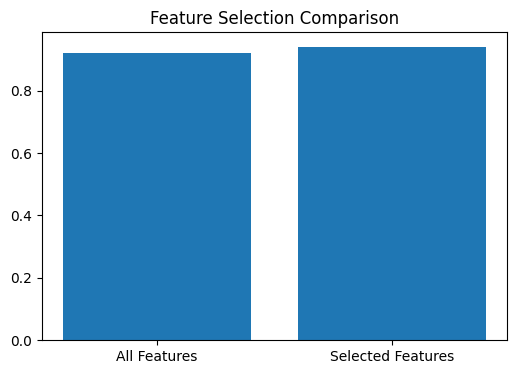

In [14]:
plt.figure(figsize=(6,4))

plt.bar(
    comparison["Approach"],
    comparison["Accuracy"]
)

plt.title(
    "Feature Selection Comparison"
)

plt.show()

## Conclusion

Random Forest feature importance was used to identify the most influential features.

Observations:
- Some features contributed more than others.
- Feature selection reduced the number of input variables.
- A simpler model can sometimes maintain similar performance.
- Feature importance helps improve interpretability.